### Plasmid Embeddings Visualization

#### 1. Function of this notebook
This notebook visualizes plasmid sequence embeddings from PlasmidGPT. It includes:
- t-SNE visualization of Voigt lab plasmids colored by publication year
- t-SNE visualization of Voigt lab plasmids colored by publication
- t-SNE visualization of Zhang lab plasmids colored by publication year
- t-SNE visualization of Zhang lab plasmids colored by publication
- t-SNE visualization of all Addgene labs' mean embeddings colored by vector type
- Scatter plot of plasmid diversity vs number of plasmids per lab
- Within-lab vs between-lab embedding distance analysis for top labs
- t-SNE visualization of plasmids from 20 research labs

#### 2. Input and Output
**Input files (in the same folder):**
- hidden_states_last_addgene.txt: Embeddings for all Addgene plasmids
- addgene_lab_cleaned.txt: Lab indices for each plasmid (index 27 = Voigt lab, index 2 = Feng Zhang lab)
- addgene_vector_type_cleaned.txt: Vector type indices for each plasmid
- voigt_df.csv: Metadata for Voigt lab plasmids
- zhang_df.csv: Metadata for Zhang lab plasmids
- Voigt_embeddings.txt: Embeddings for Voigt lab plasmids
- Zhang_embeddings.txt: Embeddings for Zhang lab plasmids

**Output:**
- Multiple visualization figures

#### 3. Time estimation
- Data loading: ~10-30 seconds
- t-SNE computation: ~1-5 minutes per plot (depending on data size)
- Total runtime: ~10-15 minutes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.metrics import pairwise_distances
from collections import defaultdict, Counter
from scipy import stats
import re

Voigt embeddings shape: (518, 768)
Voigt dataframe shape: (518, 105)


C:\Users\TriCityPC\AppData\Local\Temp\ipykernel_6836\154981438.py:38: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


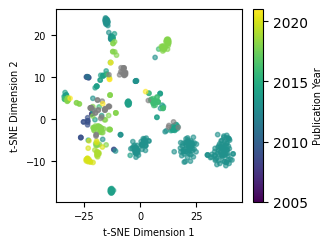

In [2]:
# Load Voigt lab data
voigt_emb = np.loadtxt("Voigt_embeddings.txt")
voigt_df = pd.read_csv("voigt_df.csv")
print(f"Voigt embeddings shape: {voigt_emb.shape}")
print(f"Voigt dataframe shape: {voigt_df.shape}")

# Extract years from publication info
def extract_year(paper):
    if pd.isna(paper) or 'unpublished' in str(paper).lower():
        return None
    year_match = re.search(r'20\d{2}|19\d{2}', str(paper))
    return int(year_match.group(0)) if year_match else None

# Get years for each Voigt plasmid
voigt_years = [extract_year(paper) for paper in voigt_df['Publication']]

# Create colormap for years
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=2005, vmax=2021)

# Create colors list
voigt_colors = []
for year in voigt_years:
    if year is None:
        voigt_colors.append('gray')
    else:
        voigt_colors.append(cmap(norm(year)))

# Perform t-SNE for Voigt lab
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
voigt_tsne = tsne.fit_transform(voigt_emb)

# Plot Voigt lab t-SNE colored by year
plt.figure(figsize=(3, 2.5))
plt.scatter(voigt_tsne[:, 0], voigt_tsne[:, 1], s=10, alpha=0.6, c=voigt_colors)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Publication Year', fontsize=7)
plt.title("", fontsize=7)
plt.xlabel("t-SNE Dimension 1", fontsize=7)
plt.ylabel("t-SNE Dimension 2", fontsize=7)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

plt.show()

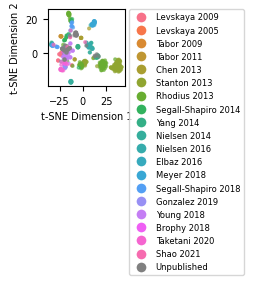

In [11]:
# Plot Voigt lab t-SNE colored by publication
def get_short_citation(paper):
    first_author = paper.split()[0]
    year_match = re.search(r'20\d{2}|19\d{2}', paper)
    year = year_match.group(0) if year_match else ''
    return f"{first_author} {year}"

# Get unique publications, excluding unpublished ones
voigt_published_papers = [paper for paper in voigt_df['Publication'].unique() 
                          if 'unpublished' not in str(paper).lower() and not pd.isna(paper)]

# Create color mapping for published papers
voigt_pub_colors = sns.color_palette('husl', n_colors=len(voigt_published_papers))
voigt_paper_color_map = dict(zip(voigt_published_papers, voigt_pub_colors))

# Create a list of colors for each point
voigt_point_colors = []
for paper in voigt_df['Publication']:
    if pd.isna(paper) or 'unpublished' in str(paper).lower():
        voigt_point_colors.append('gray')
    else:
        voigt_point_colors.append(voigt_paper_color_map.get(paper, 'gray'))

# Plot
plt.figure(figsize=(1, 1))
plt.scatter(voigt_tsne[:, 0], voigt_tsne[:, 1], s=4, alpha=0.6, c=voigt_point_colors)

legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                            markerfacecolor=color, label=get_short_citation(paper), 
                            markersize=8)
                  for paper, color in voigt_paper_color_map.items()]
legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                markerfacecolor='gray', label='Unpublished',
                                markersize=8))

plt.legend(handles=legend_elements, 
          bbox_to_anchor=(1.05, 1),
          loc='upper left',
          borderaxespad=0.,
          fontsize=6)
plt.title("", fontsize=7)
plt.xlabel("t-SNE Dimension 1", fontsize=7)
plt.ylabel("t-SNE Dimension 2", fontsize=7)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

plt.show()

Zhang embeddings shape: (4081, 768)
Zhang dataframe shape: (4081, 105)


C:\Users\TriCityPC\AppData\Local\Temp\ipykernel_6836\3677446666.py:30: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


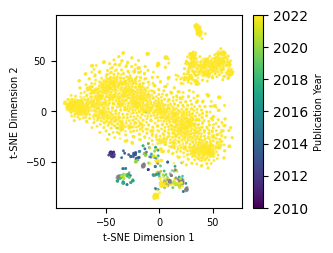

In [3]:
zhang_emb = np.loadtxt("Zhang_embeddings.txt")
zhang_df = pd.read_csv("zhang_df.csv")
print(f"Zhang embeddings shape: {zhang_emb.shape}")
print(f"Zhang dataframe shape: {zhang_df.shape}")

# Get years for each Zhang plasmid
zhang_years = [extract_year(paper) for paper in zhang_df['Publication']]

# Create colormap for years
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=2010, vmax=2022)

# Create colors list
zhang_colors = []
for year in zhang_years:
    if year is None:
        zhang_colors.append('gray')
    else:
        zhang_colors.append(cmap(norm(year)))

# Perform t-SNE for Zhang lab
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
zhang_tsne = tsne.fit_transform(zhang_emb)

# Plot Zhang lab t-SNE colored by year
plt.figure(figsize=(3, 2.5))
plt.scatter(zhang_tsne[:, 0], zhang_tsne[:, 1], s=1, alpha=0.6, c=zhang_colors)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Publication Year', fontsize=7)
plt.title("", fontsize=7)
plt.xlabel("t-SNE Dimension 1", fontsize=7)
plt.ylabel("t-SNE Dimension 2", fontsize=7)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

plt.show()

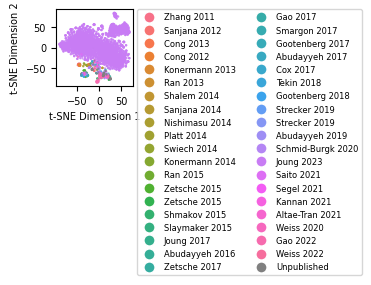

In [12]:
# Plot Zhang lab t-SNE colored by publication
zhang_published_papers = [paper for paper in zhang_df['Publication'].unique() 
                          if 'unpublished' not in str(paper).lower() and not pd.isna(paper)]

# Create color mapping for published papers
zhang_pub_colors = sns.color_palette('husl', n_colors=len(zhang_published_papers))
zhang_paper_color_map = dict(zip(zhang_published_papers, zhang_pub_colors))

# Create a list of colors for each point
zhang_point_colors = []
for paper in zhang_df['Publication']:
    if pd.isna(paper) or 'unpublished' in str(paper).lower():
        zhang_point_colors.append('gray')
    else:
        zhang_point_colors.append(zhang_paper_color_map.get(paper, 'gray'))

# Plot
plt.figure(figsize=(1, 1))
plt.scatter(zhang_tsne[:, 0], zhang_tsne[:, 1], s=0.5, alpha=0.6, c=zhang_point_colors)

legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                            markerfacecolor=color, label=get_short_citation(paper), 
                            markersize=8)
                  for paper, color in zhang_paper_color_map.items()]
legend_elements.append(plt.Line2D([0], [0], marker='o', color='w',
                                markerfacecolor='gray', label='Unpublished',
                                markersize=8))

plt.legend(handles=legend_elements, 
          bbox_to_anchor=(1.05, 1),
          loc='upper left',
          borderaxespad=0.,
          ncol=2,
          fontsize=6)
plt.title("", fontsize=7)
plt.xlabel("t-SNE Dimension 1", fontsize=7)
plt.ylabel("t-SNE Dimension 2", fontsize=7)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

plt.show()

In [4]:
# Load all Addgene data
hidden_list = np.loadtxt('hidden_states_last_addgene.txt')
continuous_array = np.loadtxt('addgene_lab_cleaned.txt')
vector_array = np.loadtxt('addgene_vector_type_cleaned.txt')
print(f"Hidden states shape: {hidden_list.shape}")
print(f"Lab array shape: {continuous_array.shape}")
print(f"Vector type array shape: {vector_array.shape}")

Hidden states shape: (121547, 768)
Lab array shape: (121547,)
Vector type array shape: (121547,)


C:\Users\TriCityPC\AppData\Local\Temp\ipykernel_6836\3385294559.py:69: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  legend_elements = [plt.scatter([], [], c=color_dict['mammalian'], label='Mammalian Lab'),
C:\Users\TriCityPC\AppData\Local\Temp\ipykernel_6836\3385294559.py:70: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([], [], c=color_dict['bacterial'], label='Bacterial Lab'),
C:\Users\TriCityPC\AppData\Local\

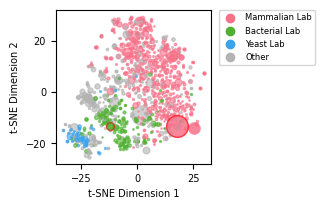

In [5]:
lab_to_hidden = defaultdict(list)
for i, lab in enumerate(continuous_array):
    lab_to_hidden[lab].append(hidden_list[i])

# Calculate mean and variation for each lab
lab_means = {}
lab_variations = {}
lab_counts = {}
for lab, states in lab_to_hidden.items():
    states = np.array(states)
    lab_means[lab] = np.mean(states, axis=0)
    lab_variations[lab] = np.mean(np.var(states, axis=0))
    lab_counts[lab] = len(states)

# Convert means to array for t-SNE
mean_array = np.array(list(lab_means.values()))

# Perform t-SNE on lab means
tsne = TSNE(n_components=2, random_state=42)
lab_tsne = tsne.fit_transform(mean_array)

# Calculate vector type proportions for each lab
lab_vector_types = defaultdict(lambda: defaultdict(int))
for lab, vec_type in zip(continuous_array, vector_array):
    lab_vector_types[lab][vec_type] += 1

# %%
# Define color scheme based on vector type
colors = sns.color_palette("husl", 3)
color_dict = {
    'mammalian': colors[0],
    'bacterial': colors[1],
    'yeast': colors[2],
    'other': (0.7, 0.7, 0.7)
}

# Determine lab colors based on vector type proportions
lab_colors = {}
labs = list(lab_means.keys())
thres = 0.5
for lab in labs:
    total = sum(lab_vector_types[lab].values())
    props = {k: v/total for k, v in lab_vector_types[lab].items()}
    
    if props.get(1, 0) + props.get(5, 0) > thres:
        lab_colors[lab] = color_dict['mammalian']
    elif props.get(2, 0) > thres:
        lab_colors[lab] = color_dict['bacterial']
    elif props.get(3, 0) > thres:
        lab_colors[lab] = color_dict['yeast']
    else:
        lab_colors[lab] = color_dict['other']

# Plot all labs t-SNE (index 27 = Voigt, index 2 = Zhang highlighted with red edge)
plt.figure(figsize=(2, 2))
for i, lab in enumerate(labs): 
    if lab != 0:
        size = lab_counts[lab] * 0.06
        plt.scatter(lab_tsne[i, 0], lab_tsne[i, 1], 
                   s=size, c=[lab_colors[lab]], alpha=0.6)

for i, lab in enumerate(labs): 
    if lab == 2 or lab == 27:
        size = lab_counts[lab] * 0.06
        plt.scatter(lab_tsne[i, 0], lab_tsne[i, 1], 
                   s=size, c=[lab_colors[lab]], alpha=0.6, edgecolor='red', linewidth=1)

plt.title('', fontsize=7)
legend_elements = [plt.scatter([], [], c=color_dict['mammalian'], label='Mammalian Lab'),
                  plt.scatter([], [], c=color_dict['bacterial'], label='Bacterial Lab'),
                  plt.scatter([], [], c=color_dict['yeast'], label='Yeast Lab'),
                  plt.scatter([], [], c=color_dict['other'], label='Other')]
plt.legend(handles=legend_elements, 
          bbox_to_anchor=(1.05, 1),
          loc='upper left',
          borderaxespad=0.,
          fontsize=6)
plt.xlabel("t-SNE Dimension 1", fontsize=7)
plt.ylabel("t-SNE Dimension 2", fontsize=7)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

plt.show()

Spearman correlation: 0.231 (p=5.60e-13)
Pearson correlation: 0.113 (p=4.99e-04)


C:\Users\TriCityPC\AppData\Local\Temp\ipykernel_6836\3862750356.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  legend_elements = [plt.scatter([], [], c=color_dict['mammalian'], label='Mammalian Lab'),
C:\Users\TriCityPC\AppData\Local\Temp\ipykernel_6836\3862750356.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([], [], c=color_dict['bacterial'], label='Bacterial Lab'),
C:\Users\TriCityPC\AppData\Local\

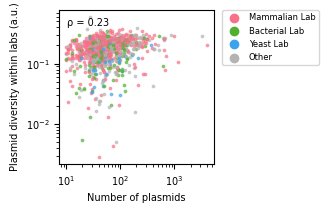

In [6]:
# Calculate correlation between plasmid count and variation
counts = [lab_counts[lab] for lab in labs if lab != 0]
variations = [lab_variations[lab] for lab in labs if lab != 0]

spearman_corr, spearman_p = stats.spearmanr(counts, variations)
pearson_corr, pearson_p = stats.pearsonr(counts, variations)
print(f"Spearman correlation: {spearman_corr:.3f} (p={spearman_p:.2e})")
print(f"Pearson correlation: {pearson_corr:.3f} (p={pearson_p:.2e})")

# Plot variation vs number of plasmids
plt.figure(figsize=(2, 2))
for lab in labs:
    if lab != 0:
        plt.scatter(lab_counts[lab], lab_variations[lab], 
                   c=[lab_colors[lab]], s=3, alpha=0.6)

plt.xlabel('Number of plasmids', fontsize=7)
plt.ylabel('Plasmid diversity within labs (a.u.)', fontsize=7)
plt.title('', fontsize=7)
legend_elements = [plt.scatter([], [], c=color_dict['mammalian'], label='Mammalian Lab'),
                  plt.scatter([], [], c=color_dict['bacterial'], label='Bacterial Lab'),
                  plt.scatter([], [], c=color_dict['yeast'], label='Yeast Lab'),
                  plt.scatter([], [], c=color_dict['other'], label='Other')]
plt.legend(handles=legend_elements, 
          bbox_to_anchor=(1.05, 1),
          loc='upper left',
          borderaxespad=0.,
          fontsize=6)
plt.text(0.05, 0.95, f'ρ = {spearman_corr:.2f}', 
         transform=plt.gca().transAxes, 
         verticalalignment='top',
         fontsize=7)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.xscale('log')
plt.yscale('log')

plt.show()

Analyzing top 100 labs


C:\Users\TriCityPC\AppData\Local\Temp\ipykernel_6836\2347219208.py:100: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([], [], c=color_dict['mammalian'], label='Mammalian Lab'),
C:\Users\TriCityPC\AppData\Local\Temp\ipykernel_6836\2347219208.py:101: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([], [], c=color_dict['bacterial'], label='Bacterial Lab'),
C:\Users\TriCityPC\AppData\Local\Temp\ipykernel_68

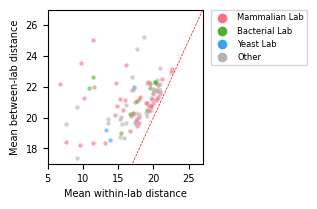

In [9]:
def to_int_1d(x):
    x = np.asarray(x)
    if x.ndim == 2 and x.shape[1] == 1:
        x = x[:, 0]
    return x.astype(int)

lab_ids = to_int_1d(continuous_array)
vec_types = to_int_1d(vector_array)

# Pick top-100 labs by count
EXCLUDE_LAB0 = True
counts_full = Counter(lab_ids)
if EXCLUDE_LAB0 and 0 in counts_full:
    del counts_full[0]

top_k = 100
top_labs = [lab for lab, _ in counts_full.most_common(top_k)]
print(f"Analyzing top {top_k} labs")

# Build index lists per lab
lab_to_idx = {lab: np.where(lab_ids == lab)[0] for lab in top_labs}
lab_sizes = {lab: len(lab_to_idx[lab]) for lab in top_labs}

# Determine color per lab from vector-type composition
lab_to_color = {}
for lab in top_labs:
    vts = vec_types[lab_to_idx[lab]]
    vt_counts = Counter(vts)
    total = sum(vt_counts.values())
    props = {k: vt_counts[k] / total for k in vt_counts} if total > 0 else {}

    if props.get(1, 0) + props.get(5, 0) > thres:
        lab_to_color[lab] = color_dict['mammalian']
    elif props.get(2, 0) > thres:
        lab_to_color[lab] = color_dict['bacterial']
    elif props.get(3, 0) > thres:
        lab_to_color[lab] = color_dict['yeast']
    else:
        lab_to_color[lab] = color_dict['other']

# %%
# Efficient mean distance computations
rng = np.random.default_rng(42)
MAX_WITHIN_PER_LAB = 1000
MAX_BETWEEN_POOL = 10000

def mean_within_distance(X):
    """Mean of upper-triangular Euclidean distances inside X."""
    if X.shape[0] < 2:
        return np.nan
    D = pairwise_distances(X, metric='euclidean')
    iu = np.triu_indices_from(D, k=1)
    return D[iu].mean()

def mean_between_distance(X_lab, X_others):
    """Mean Euclidean distance between two sets."""
    if X_lab.shape[0] == 0 or X_others.shape[0] == 0:
        return np.nan
    D = pairwise_distances(X_lab, X_others, metric='euclidean')
    return D.mean()

# Build "other" pool (samples NOT in top labs) 
other_mask = ~np.isin(lab_ids, top_labs)
other_indices = np.where(other_mask)[0]
if len(other_indices) > MAX_BETWEEN_POOL:
    other_indices = rng.choice(other_indices, MAX_BETWEEN_POOL, replace=False)
X_others = hidden_list[other_indices]

# Compute stats for each lab
lab_stats = []
for lab in top_labs:
    idx = lab_to_idx[lab]
    if len(idx) > MAX_WITHIN_PER_LAB:
        idx = rng.choice(idx, MAX_WITHIN_PER_LAB, replace=False)
    X_lab = hidden_list[idx]
    
    w = mean_within_distance(X_lab)
    b = mean_between_distance(X_lab, X_others)
    
    lab_stats.append({
        'lab': lab,
        'size': lab_sizes[lab],
        'within': w,
        'between': b,
        'color': lab_to_color[lab]
    })

# %%
# Plot within-lab vs between-lab distance
plt.figure(figsize=(2, 2))
plt.rcParams['font.size'] = 7

for s in lab_stats:
    s_val = 10
    plt.scatter(s['within'], s['between'], s=s_val, c=[s['color']], alpha=0.6, linewidths=0)

plt.plot(np.arange(30), np.arange(30), 'r--', linewidth=0.5)

legend_elements = [
    plt.scatter([], [], c=color_dict['mammalian'], label='Mammalian Lab'),
    plt.scatter([], [], c=color_dict['bacterial'], label='Bacterial Lab'),
    plt.scatter([], [], c=color_dict['yeast'], label='Yeast Lab'),
    plt.scatter([], [], c=color_dict['other'], label='Other')
]
plt.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=6
)

plt.xlabel("Mean within-lab distance", fontsize=7)
plt.ylabel("Mean between-lab distance", fontsize=7)
plt.xlim([5, 27])
plt.ylim([17, 27])
plt.title("", fontsize=7)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

plt.show()

Top-20 labs (full dataset): [(2, 4050), (4, 3206), (6, 1153), (3, 979), (8, 871), (14, 711), (15, 682), (17, 669), (12, 650), (21, 644), (22, 640), (16, 638), (18, 622), (20, 617), (26, 533), (27, 516), (28, 507), (33, 432), (9, 427), (36, 425)]
Kept 18972 samples from 20 labs.


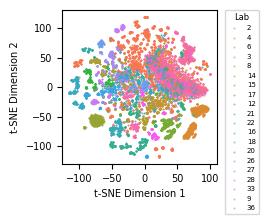

In [10]:
def to_int_1d(x):
    x = np.asarray(x)
    if x.ndim == 2 and x.shape[1] == 1:
        x = x[:, 0]
    return x.astype(int)

lab_ids = to_int_1d(continuous_array)

# --- Pick top-20 labs by count from the FULL dataset ---
EXCLUDE_LAB0 = True  # set to False if lab 0 is a valid lab for you
lab_counts_full = Counter(lab_ids)
if EXCLUDE_LAB0 and 0 in lab_counts_full:
    del lab_counts_full[0]

major_labs = [lab for lab, _ in lab_counts_full.most_common(20)]
print("Top-20 labs (full dataset):", [(lab, lab_counts_full[lab]) for lab in major_labs])

# --- Keep ALL samples from these labs (no subsampling) ---
keep_mask = np.isin(lab_ids, major_labs)
X_keep = hidden_list[keep_mask]
labs_keep = lab_ids[keep_mask]
print(f"Kept {X_keep.shape[0]} samples from {len(major_labs)} labs.")

# --- Assign a UNIQUE color per lab (husl palette with as many colors as labs) ---
palette = sns.color_palette("husl", len(major_labs))
lab_to_color = {lab: palette[i] for i, lab in enumerate(major_labs)}

# --- t-SNE on per-sample embeddings ---
# Note: t-SNE can be slow on large N; consider lowering perplexity or using PCA first if needed.
tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto", perplexity=30)
tsne_results = tsne.fit_transform(X_keep)  # (n_points, 2)

# --- Plot (tiny fig, font 7, per-lab colors) ---
plt.figure(figsize=(2, 2))
plt.rcParams['font.size'] = 7

for lab in major_labs:
    m = (labs_keep == lab)
    if not np.any(m):
        continue
    plt.scatter(
        tsne_results[m, 0], tsne_results[m, 1],
        s=2, alpha=0.6, c=[lab_to_color[lab]], linewidths=0, label=str(lab)
    )

# Legend with lab IDs (20 items), placed outside to save space
plt.legend(
    title="Lab", fontsize=5, title_fontsize=6,
    bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.
)

plt.title("", fontsize=7)
plt.xlabel("t-SNE Dimension 1", fontsize=7)
plt.ylabel("t-SNE Dimension 2", fontsize=7)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

plt.show()